### 📘 Quantum Metrology Simulation with MrMustard

This notebook **MrMustard** to simulate a quantum-enhanced phase estimation scheme using **Two-Mode Squeezed Vacuum (TMSV)** states in a Mach–Zehnder interferometer, inspired by:

> **You, C., Hong, M., Bierhorst, P., Lita, A. E., Glancy, S., Kolthammer, S., Knill, E., Nam, S. W., Mirin, R. P., Magaña-Loaiza, O. S., & Gerrits, T.**
> *Scalable multiphoton quantum metrology with neither pre- nor post-selected measurements*.
> *Applied Physics Reviews*, 8(4), 041410 (2021).
> [https://doi.org/10.1063/5.0054722](https://doi.org/10.1063/5.0054722)

> For documentation of MrMustard, visit: [https://mrmustard.readthedocs.io/en/stable/development/development_guide.html](https://mrmustard.readthedocs.io/en/stable/development/development_guide.html)

In [10]:
# We do the usual imports
import numpy as np
np.set_printoptions(legacy="1.13")
from mrmustard.lab import *
import mrmustard.math as math
from mrmustard.physics import fidelity
from mrmustard.training import Optimizer
from mrmustard.lab.gates import BSgate, Sgate
from mrmustard.lab.circuit import Circuit


### Detection Probabilities of Two-Mode Squeezed Vacuum (TMSV) via Click Detection

Scheme 1 simulation time: 9.8338 seconds


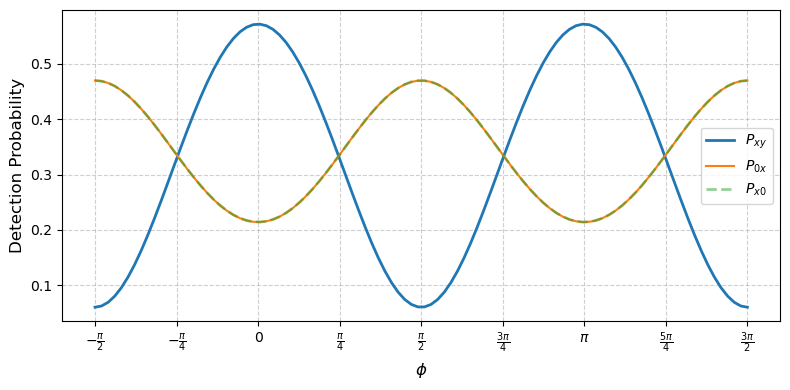

In [21]:
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from mrmustard.lab import Sgate, MZgate, Vacuum, Fock

# Format π-ticks
def format_pi(x, pos):
    frac = x / np.pi
    if np.isclose(frac, 0): return "0"
    elif np.isclose(frac, 0.5): return r"$\frac{\pi}{2}$"
    elif np.isclose(frac, 1): return r"$\pi$"
    elif np.isclose(frac, 1.5): return r"$\frac{3\pi}{2}$"
    elif np.isclose(frac, 2): return r"$2\pi$"
    elif np.isclose(frac, -0.5): return r"$-\frac{\pi}{2}$"
    elif np.isclose(frac, -0.25): return r"$-\frac{\pi}{4}$"
    elif np.isclose(frac, 0.25): return r"$\frac{\pi}{4}$"
    elif np.isclose(frac, 0.75): return r"$\frac{3\pi}{4}$"
    elif np.isclose(frac, 1.25): return r"$\frac{5\pi}{4}$"
    else: return f"{frac:.2g}π"

cutoff = 15
phi_vals = np.linspace(-np.pi/2, 3*np.pi/2, 100)

P00_list,P0x_list, Px0_list, Pxy_list = [],[], [], []

start_time_1 = time.time()
for phi_bs in phi_vals:
    M = MZgate(phi_a=0.0, phi_b=phi_bs)
    state = TMSV(r=0.5) >> M
    state._cutoffs = [cutoff, cutoff]

    P00 = state << Fock(n=[0, 0], modes=[0, 1])
    P0x = sum(state << Fock(n=[0, n], modes=[0, 1]) for n in range(1, cutoff))
    Px0 = sum(state << Fock(n=[n, 0], modes=[0, 1]) for n in range(1, cutoff))
    Pxy = sum(state << Fock(n=[n, m], modes=[0, 1]) for n in range(1, cutoff) for m in range(1, cutoff))
    P00_list.append(P00)
    P0x_list.append(P0x)
    Px0_list.append(Px0)
    Pxy_list.append(Pxy)
end_time_1 = time.time()

print(f"Scheme 1 simulation time: {end_time_1 - start_time_1:.4f} seconds")

# Define ticks and labels for phi axis
tick_locs = [-np.pi/2, -np.pi/4, 0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi, 5*np.pi/4, 3*np.pi/2]
tick_labels = [
    r"$-\frac{\pi}{2}$", r"$-\frac{\pi}{4}$", r"$0$", r"$\frac{\pi}{4}$",
    r"$\frac{\pi}{2}$", r"$\frac{3\pi}{4}$", r"$\pi$",
    r"$\frac{5\pi}{4}$", r"$\frac{3\pi}{2}$"
]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(phi_vals1, P11_list, label=r'$P_{xy}$', linewidth=2)
ax.plot(phi_vals1, P02_list, label=r'$P_{0x}$',linewidth=1.5, linestyle='-', alpha=1.0)
ax.plot(phi_vals1, P20_list, label=r'$P_{x0}$', linewidth=2.0, linestyle='--', alpha=0.5)


ax.set_xlabel(r'$\phi$', fontsize=12)
ax.set_ylabel('Detection Probability', fontsize=12)

ax.set_xticks(tick_locs)
ax.set_xticklabels(tick_labels, fontsize=10)

ax.xaxis.set_major_formatter(FuncFormatter(format_pi))
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



###  Fisher Information in Ideal (Lossless) Conditions

<>:104: SyntaxWarning: invalid escape sequence '\m'
<>:104: SyntaxWarning: invalid escape sequence '\m'
C:\Users\world\AppData\Local\Temp\ipykernel_22584\589666094.py:104: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("Normalized Fisher Info($\mathrm{rad}^{-2}$)", fontsize=12)


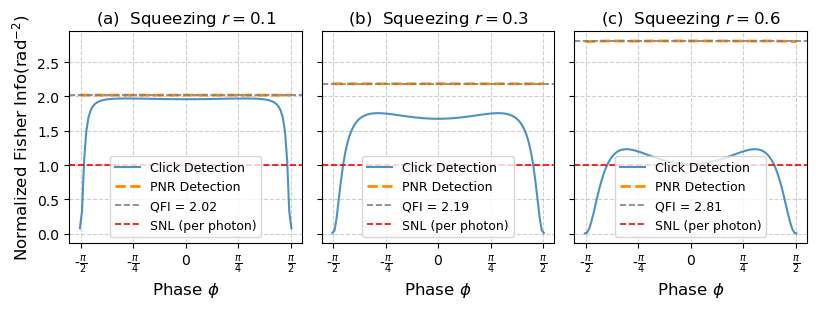

In [12]:

import math
import os

# --- Parameters ---
delta_phi = 1e-5
phi_vals = np.linspace(-np.pi/2-0.01, np.pi/2+0.01, 100)
cutoff = 20
transmissivity = 0.9
r_values = [0.1, 0.3, 0.6]

# --- Click Detection ---
def get_probs_click(phi, r_squeeze, loss=False):
    state = Vacuum(2) >> Sgate(r=[r_squeeze, r_squeeze], phi=[0.0, np.pi]) >> BSgate(theta=-np.pi/4) >> MZgate(phi_a=0.0, phi_b=phi) 
    state = TMSV(r=r_squeeze) >> MZgate(phi_a=0.0, phi_b=phi) 
    final_ket = state.ket(cutoffs=[cutoff, cutoff])
    state_norm = final_ket / math.sqrt(np.sum(np.abs(final_ket)**2))
    state = State(ket=state_norm)

    if loss:
        state = state >> Attenuator(transmissivity=transmissivity)[0] >> Attenuator(transmissivity=transmissivity)[1]

    P00 = state << Fock(n=[0, 0], modes=[0, 1])
    P0x = sum(state << Fock(n=[0, n], modes=[0, 1]) for n in range(1, cutoff))
    Px0 = sum(state << Fock(n=[n, 0], modes=[0, 1]) for n in range(1, cutoff))
    Pxy = sum(state << Fock(n=[n, m], modes=[0, 1]) for n in range(1, cutoff) for m in range(1, cutoff))
    
    return {
        'P00': P00 ,
        'P0x': P0x ,
        'Px0': Px0 ,
        'Pxy': Pxy 
    }

# --- PNR Detection ---
def get_probs_pnr(phi, r_squeeze, loss=False):
    state = Vacuum(2) >> Sgate(r=[r_squeeze, r_squeeze], phi=[0.0, np.pi]) >> BSgate(theta=-np.pi/4) >> MZgate(phi_a=0.0, phi_b=phi) 
    state = TMSV(r=r_squeeze) >> MZgate(phi_a=0.0, phi_b=phi) 
    if loss:
        state = state >> Attenuator(transmissivity=transmissivity)[0] >> Attenuator(transmissivity=transmissivity)[1]

    probs = {}
    for n in range(cutoff):
        for m in range(cutoff):
            key = f"{n}{m}"
            probs[key] = state << Fock(n=[n, m], modes=[0, 1])
    return probs

# --- Fisher Information Calculator ---
def compute_fisher_info(get_probs_fn, r_squeeze, loss=False):
    fisher_info = []
    n = 2 * (np.sinh(r_squeeze))**2
    for phi in phi_vals:
        probs_mid = get_probs_fn(phi, r_squeeze, loss=loss)
        probs_plus = get_probs_fn(phi + delta_phi, r_squeeze, loss=loss)
        probs_minus = get_probs_fn(phi - delta_phi, r_squeeze, loss=loss)
        FI = 0.0
        for key in probs_mid:
            p = max(probs_mid[key], 1e-12)
            p_plus = max(probs_plus.get(key, 1e-12), 1e-12)
            p_minus = max(probs_minus.get(key, 1e-12), 1e-12)
            dlnp = (np.log(p_plus) - np.log(p_minus)) / (2 * delta_phi)
            FI += p * dlnp**2
        fisher_info.append(FI / n)
    return np.array(fisher_info)

# --- Quantum Fisher Information ---
def compute_qfi_pnr(r_squeeze, eta1, eta2):
    n = 2 * np.sinh(r_squeeze)**2
    numerator =  2*(n + 2) * eta1 * eta2
    denominator = 2 + n * (eta1 + eta2 - 2 * eta1 * eta2)
    FQ = numerator /denominator
    return FQ

# --- Plotting ---
fig, axs = plt.subplots(1, 3, figsize=(8.27, 3.2), sharey=True)  # A4 width

subplot_labels = ['(a)', '(b)', '(c)']
# --- Custom X-axis ticks ---
tick_locs = [-np.pi/2,-np.pi/4, 0, np.pi/4, np.pi/2]
tick_labels = [r"-$\frac{\pi}{2}$", r"-$\frac{\pi}{4}$","$0$", r"$\frac{\pi}{4}$", r"$\frac{\pi}{2}$"]

subplot_labels = ['(a)', '(b)', '(c)']

for idx, r_val in enumerate(r_values):
    fi_click = compute_fisher_info(get_probs_click, r_squeeze=r_val, loss=False)
    fi_pnr = compute_fisher_info(get_probs_pnr, r_squeeze=r_val, loss=False)
    qfi = compute_qfi_pnr(r_val, 1.0, 1.0)
    
    n = 2 * (np.sinh(r_val))**2
    snl = n / (n)  # This simplifies to 2, but written explicitly for clarity

    ax = axs[idx]
    ax.plot(phi_vals, fi_click, label="Click Detection",linewidth=1.5, linestyle='-', alpha=0.8)
    ax.plot(phi_vals, fi_pnr, label="PNR Detection", color="darkorange", linewidth=2.0, linestyle='--', alpha=1.0)
    ax.axhline(qfi, linestyle='--', color='gray', label=f"QFI = {qfi:.2f}", linewidth=1.2)
    ax.axhline(snl, color='red', linestyle='--', label="SNL (per photon)", linewidth=1.2)

    ax.set_title(f"{subplot_labels[idx]}  Squeezing $r = {r_val}$", fontsize=12)
    ax.set_xlabel(r"Phase $\phi$", fontsize=12)
    ax.set_xticks(tick_locs)
    ax.set_xticklabels(tick_labels, fontsize=10)
    ax.tick_params(axis='y', labelsize=10)
    if idx == 0:
        ax.set_ylabel("Normalized Fisher Info($\mathrm{rad}^{-2}$)", fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=9)


plt.tight_layout()
plt.show()


###  Fisher Information under Loss

<>:105: SyntaxWarning: invalid escape sequence '\m'
<>:105: SyntaxWarning: invalid escape sequence '\m'
C:\Users\world\AppData\Local\Temp\ipykernel_22584\1180172906.py:105: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("Normalized Fisher Info ($\mathrm{rad}^{-2}$)", fontsize=12)


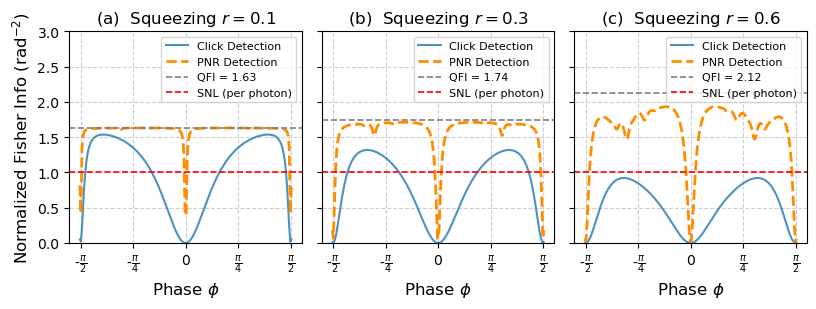

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from mrmustard.lab import Sgate, MZgate, Fock, Vacuum, Attenuator, BSgate, S2gate, State
import math
import os

# --- Parameters ---
delta_phi = 1e-5
phi_vals = np.linspace(-np.pi/2-0.01, np.pi/2+0.01, 200)
cutoff = 10
transmissivity = 0.9
r_values = [0.1, 0.3, 0.6]

# --- Click Detection ---
def get_probs_click(phi, r_squeeze, loss=False):
    state = Vacuum(2) >> Sgate(r=[r_squeeze, r_squeeze], phi=[0.0, np.pi]) >> BSgate(theta=-np.pi/4) >> MZgate(phi_a=0.0, phi_b=phi) >> Attenuator(transmissivity=0.9)[0]>> Attenuator(transmissivity=0.9)[1]
    state = TMSV(r=r_squeeze) >> MZgate(phi_a=0.0, phi_b=phi)  >> Attenuator(transmissivity=0.9)[0]>> Attenuator(transmissivity=0.9)[1]

    if loss:
        state = state >> Attenuator(transmissivity=transmissivity)[0] >> Attenuator(transmissivity=transmissivity)[1]

    P00 = state << Fock(n=[0, 0], modes=[0, 1])
    P0x = sum(state << Fock(n=[0, n], modes=[0, 1]) for n in range(1, cutoff))
    Px0 = sum(state << Fock(n=[n, 0], modes=[0, 1]) for n in range(1, cutoff))
    Pxy = sum(state << Fock(n=[n, m], modes=[0, 1]) for n in range(1, cutoff) for m in range(1, cutoff))
    
    return {
        'P00': P00 ,
        'P0x': P0x ,
        'Px0': Px0 ,
        'Pxy': Pxy 
    }

# --- PNR Detection ---
def get_probs_pnr(phi, r_squeeze, loss=False):
    
    state = TMSV(r=r_squeeze) >> MZgate(phi_a=0.0, phi_b=phi)  >> Attenuator(transmissivity=0.9)[0]>> Attenuator(transmissivity=0.9)[1]
    if loss:
        state = state >> Attenuator(transmissivity=transmissivity)[0] >> Attenuator(transmissivity=transmissivity)[1]

    probs = {}
    for n in range(cutoff):
        for m in range(cutoff):
            key = f"{n}{m}"
            probs[key] = state << Fock(n=[n, m], modes=[0, 1])
    return probs

# --- Fisher Information Calculator ---
def compute_fisher_info(get_probs_fn, r_squeeze, loss=False):
    fisher_info = []
    n = 2 * (np.sinh(r_squeeze))**2
    for phi in phi_vals:
        probs_mid = get_probs_fn(phi, r_squeeze, loss=loss)
        probs_plus = get_probs_fn(phi + delta_phi, r_squeeze, loss=loss)
        probs_minus = get_probs_fn(phi - delta_phi, r_squeeze, loss=loss)
        FI = 0.0
        for key in probs_mid:
            p = max(probs_mid[key], 1e-12)
            p_plus = max(probs_plus.get(key, 1e-12), 1e-12)
            p_minus = max(probs_minus.get(key, 1e-12), 1e-12)
            dlnp = (np.log(p_plus) - np.log(p_minus)) / (2 * delta_phi)
            FI += p * dlnp**2
        fisher_info.append(FI / n)
    return np.array(fisher_info)

# --- Quantum Fisher Information ---
def compute_qfi_pnr(r_squeeze, eta1, eta2):
    n = 2 * np.sinh(r_squeeze)**2
    numerator =  2*(n + 2) * eta1 * eta2
    denominator = 2 + n * (eta1 + eta2 - 2 * eta1 * eta2)
    FQ = numerator /denominator
    return FQ

# --- Plotting ---
fig, axs = plt.subplots(1, 3, figsize=(8.27, 3.2), sharey=True)  # A4 width

subplot_labels = ['(a)', '(b)', '(c)']
# --- Custom X-axis ticks ---
tick_locs = [-np.pi/2,-np.pi/4, 0, np.pi/4, np.pi/2]
tick_labels = [r"-$\frac{\pi}{2}$", r"-$\frac{\pi}{4}$","$0$", r"$\frac{\pi}{4}$", r"$\frac{\pi}{2}$"]

subplot_labels = ['(a)', '(b)', '(c)']

for idx, r_val in enumerate(r_values):
    fi_click = compute_fisher_info(get_probs_click, r_squeeze=r_val, loss=False)
    fi_pnr = compute_fisher_info(get_probs_pnr, r_squeeze=r_val, loss=False)
    qfi = compute_qfi_pnr(r_val, 0.9, 0.9)
    
    n = 2 * (np.sinh(r_val))**2
    snl = n / (n)  # This simplifies to 1, but written explicitly for clarity

    ax = axs[idx]
    ax.plot(phi_vals, fi_click, label="Click Detection", linewidth=1.5, linestyle='-', alpha=0.8)
    ax.plot(phi_vals, fi_pnr, label="PNR Detection", color="darkorange", linewidth=2.0, linestyle='--', alpha=1.0)
    ax.axhline(qfi, linestyle='--', color='gray', label=f"QFI = {qfi:.2f}", linewidth=1.2)
    ax.axhline(snl, color='red', linestyle='--', label="SNL (per photon)", linewidth=1.2)

    ax.set_title(f"{subplot_labels[idx]}  Squeezing $r = {r_val}$", fontsize=12)
    ax.set_xlabel(r"Phase $\phi$", fontsize=12)
    ax.set_xticks(tick_locs)
    ax.set_xticklabels(tick_labels, fontsize=10)
    ax.tick_params(axis='y', labelsize=10)
    ax.set_ylim(0, 3.0)  # <--- Set y-axis limit
    if idx == 0:
        ax.set_ylabel("Normalized Fisher Info ($\mathrm{rad}^{-2}$)", fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=8, loc='upper right')  # <--- Set legend position


plt.tight_layout()

plt.show()


### Quantum Fischer Information for TMSV

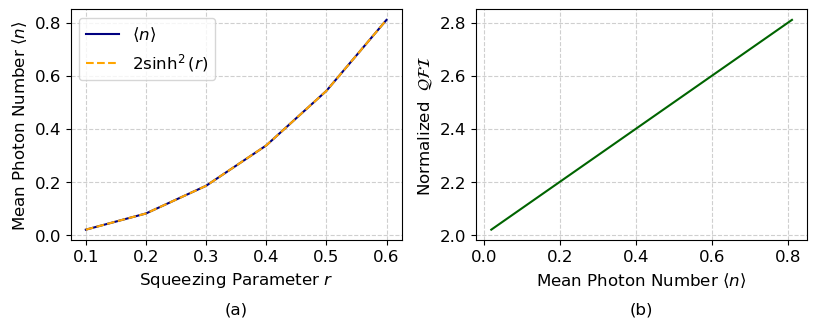

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from mrmustard.lab import Sgate, Vacuum, MZgate

# Squeezing parameter range
r_vals = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
mean_photon_nums = []

# Loop over r values to compute average total mean photon number
for r in r_vals:
    mean_photons = []
    
    for phi in np.linspace(0, 2*np.pi, 200):  # resolution in φ
        S = Sgate(r=[r, r], phi=[0.0, np.pi/2])
        M = MZgate(phi_a=0.0, phi_b=phi)
        state = Vacuum(2) >> S >> M
        means = state.number_means  # shape (2,)
        mean_photons.append(means)
    
    # Convert to array and compute average total mean photon number
    mean_photons = np.array(mean_photons)  # shape (200, 2)
    total_photons_per_phi = np.sum(mean_photons, axis=1)  # sum mode 0 and 1
    avg_total = np.mean(total_photons_per_phi)
    mean_photon_nums.append(avg_total)

mean_photon_nums = np.array(mean_photon_nums)

# Compute QFI = 4⟨n⟩(1 + ⟨n⟩)
QFI_vals =  (2 + mean_photon_nums)

# Compute 2 * sinh^2(r)
two_sinh_sq = 2 * (np.sinh(r_vals)**2)

# Plotting with A4 size in landscape (width x height)
fig, axs = plt.subplots(1, 2, figsize=(8.27, 3.5))

# Subplot 1: QFI vs mean photon number
axs[1].plot(mean_photon_nums, QFI_vals, color='darkgreen', linewidth=1.5)
axs[1].set_xlabel(r'Mean Photon Number $\langle n \rangle$', fontsize=12)
axs[1].set_ylabel(r'Normalized  $\mathcal{QFI}$', fontsize=12)
axs[1].grid(True, linestyle='--', alpha=0.6)
axs[1].tick_params(axis='both', labelsize=12)

# Subplot 2: Mean photon number vs squeezing r
axs[0].plot(r_vals, mean_photon_nums, color='navy', linewidth=1.5, label=r'$\langle n \rangle$')
axs[0].plot(r_vals, two_sinh_sq, color='orange', linestyle='--', linewidth=1.5, label=r'$2 \sinh^2(r)$')
axs[0].set_xlabel(r'Squeezing Parameter $r$', fontsize=12)
axs[0].set_ylabel(r'Mean Photon Number $\langle n \rangle$', fontsize=12)
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].tick_params(axis='both', labelsize=12)
axs[0].legend(fontsize=12)
axs[0].text(0.5, -0.32, "(a)", transform=axs[0].transAxes, fontsize=12, ha='center')  # Subcaption (a)
axs[1].text(0.5, -0.32, "(b)", transform=axs[1].transAxes, fontsize=12, ha='center')  # Subcaption (b)

plt.tight_layout()

plt.show()


### Numerical Accuracy Assessment via Cutoff Dependence

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from mrmustard.lab import TMSV, SqueezedVacuum, DisplacedSqueezed
import mrmustard.physics as p

# --- Parameters ---
cutoff_range = range(1, 100, 5)
r_values = [0.1, 0.3, 0.6, 0.8, 1.2, 1.4, 1.6, 1.8, 2.0]
reference_cutoff = 100

# --- Safe State Construction ---
def safe_normalize(state):
    norm = p.norm(state)
    return state / np.sqrt(norm) if norm > 0 else state

def compute_fidelity_vs_cutoff(state_func, r_vals, cutoff_range, reference_cutoff):
    fidelity_results = {}
    for r in r_vals:
        fidelities = []
        state_ref = safe_normalize(state_func(r, reference_cutoff))
        for cutoff in cutoff_range:
            approx_state = safe_normalize(state_func(r, cutoff))
            fid = p.fidelity(state_ref, approx_state)
            fidelities.append(fid)
        fidelity_results[r] = fidelities
    return fidelity_results

# --- State Constructors ---
def tmsv_state(r, cutoff): return TMSV(r=r, cutoffs=[cutoff, cutoff])
def squeezed_vacuum_state(r, cutoff): return SqueezedVacuum(r=r, cutoffs=[cutoff])
def displaced_squeezed_state(r, cutoff): return DisplacedSqueezed(r=r, cutoffs=[cutoff])

# --- Compute Fidelities ---
fids_tmsv = compute_fidelity_vs_cutoff(tmsv_state, r_values, cutoff_range, reference_cutoff)
fids_sv = compute_fidelity_vs_cutoff(squeezed_vacuum_state, r_values, cutoff_range, reference_cutoff)
fids_ds = compute_fidelity_vs_cutoff(displaced_squeezed_state, r_values, cutoff_range, reference_cutoff)

# --- Plotting Setup ---
fig, axs = plt.subplots(1, 3, figsize=(8.5, 3.0), dpi=300, sharey=True)
cmap = plt.cm.viridis
norm = plt.Normalize(vmin=min(r_values), vmax=max(r_values))

# Custom log tick formatter
def custom_log_formatter(x, pos):
    if np.isclose(x, 1.0): return "1"
    exponent = int(np.log10(x))
    return f"$10^{{{exponent}}}$"

custom_ticks = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1]

# Global legend storage
global_handles, global_labels = [], []

# --- Plotting Function ---
def plot_panel(ax, data_dict, label_text):
    for r in r_values:
        color = cmap(norm(r))
        rescaled_fids = [1 - f if not np.isnan(f) else 1 for f in data_dict[r]]
        line, = ax.semilogy(cutoff_range, rescaled_fids, marker='o', linestyle='-', color=color,
                            label=f"$r={r}$", markersize=2)
        if label_text == "(a) TMSV":
            global_handles.append(line)
            global_labels.append(f"$r={r}$")

    ax.set_xlabel("Fock Cutoff $n$", fontsize=11)
    ax.set_xticks(range(0, 101, 10))
    ax.set_xticklabels([str(i) for i in range(0, 101, 10)], rotation=45)
    ax.set_yticks(custom_ticks)
    ax.set_ylim(min(custom_ticks), max(custom_ticks))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(custom_log_formatter))
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.tick_params(labelsize=10)
    ax.text(0.02, 1.07, label_text, transform=ax.transAxes, fontsize=10)

# --- Create Panels ---
axs[0].set_ylabel("$1 - F$", fontsize=12)
plot_panel(axs[0], fids_tmsv, "(a) TMSV")
plot_panel(axs[1], fids_sv, "(b) Squeezed Vacuum")
plot_panel(axs[2], fids_ds, "(c) Displaced Squeezed")

# --- Global Legend ---
fig.legend(global_handles, global_labels, loc='center right', title="Squeezing $r$",
           fontsize=10, title_fontsize=10, frameon=False)

plt.tight_layout(rect=[0, 0, 0.87, 1])  # Adjust for legend
plt.show()


### 📊 Detection Probabilities and Normalization Accuracy

This cell plots two key results for a TMSV input in a Mach–Zehnder Interferometer (MZI):

* **(a)** Detection probabilities $P_{nm}$ vs. interferometric phase $\phi$ for significant photon-number outcomes $(n, m)$.
* **(b)** Average deviation from total unit probability $\sum_{nm} P_{nm}$ vs. Fock cutoff, evaluated at a squeezing parameter $r = 0.5$.

These plots demonstrate both the behavior of key measurement outcomes across phase shifts and the convergence of probability normalization with increasing Hilbert space dimension.

Main loop execution time: 1.25 seconds


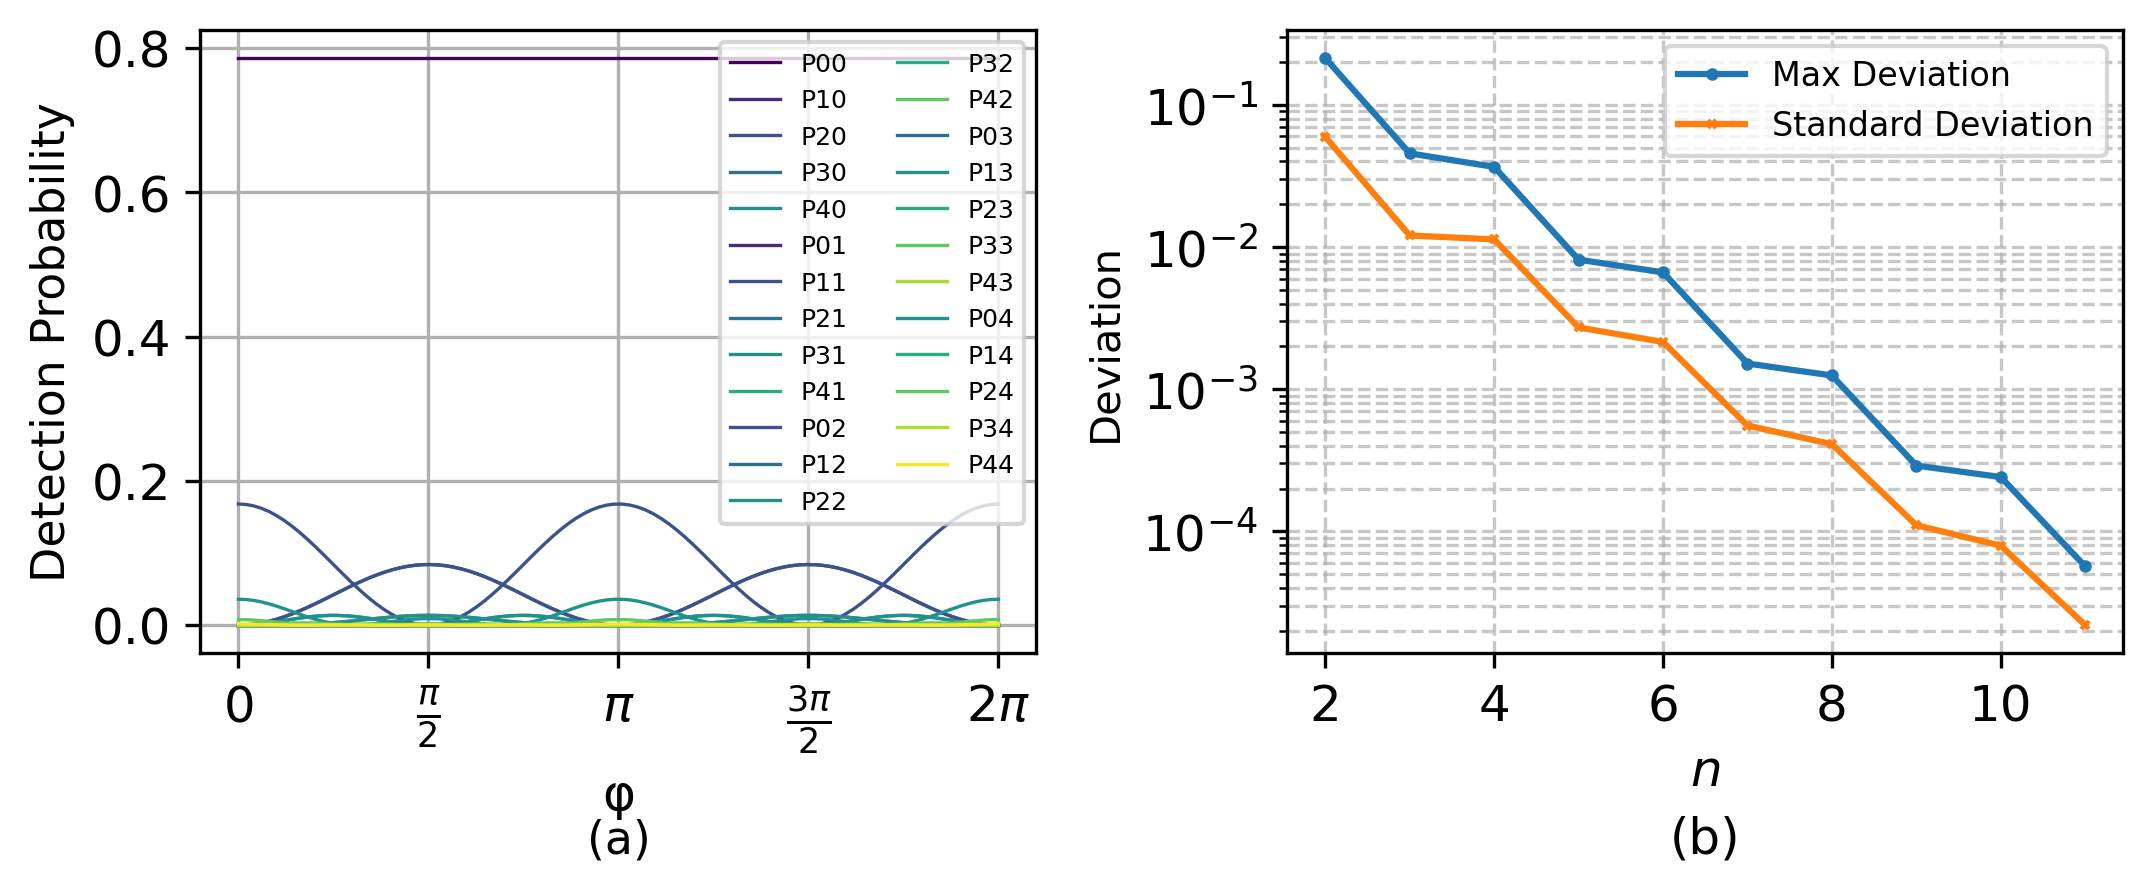

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from mrmustard.lab import Fock, MZgate, Sgate, BSgate, Vacuum
import mrmustard.physics as p
import os
import time

# --- Common Parameters ---
phi_vals = np.linspace(0.0, 2 * np.pi, 100)
r_squeeze = 0.5
initial_cutoff = 12
fock_states = [(n, m) for m in range(0, 5) for n in range(0, 5)]
prob_lists = {f"{n}{m}": [] for (n, m) in fock_states}

# --- Compute Probabilities for subplot (a) ---
mean_photons = []
start_time = time.time()
for phi_bs in phi_vals:
    M = MZgate(phi_a=0.0, phi_b=phi_bs)
    state = (Vacuum(2) >> Sgate(r=[r_squeeze, r_squeeze], phi=[0.0, np.pi])
             >> BSgate(theta=-np.pi / 4) >> M)
    state._cutoffs = [initial_cutoff, initial_cutoff]
    p.normalize(state)
    means = state.number_means
    mean_photons.append(np.sum(means))
    for (n, m) in fock_states:
        prob = state << Fock(n=[n, m], modes=[0, 1])
        prob_lists[f"{n}{m}"].append(prob)
end_time = time.time()
print(f"Main loop execution time: {end_time - start_time:.2f} seconds")

# --- Prepare probabilities ---
for key in prob_lists:
    prob_lists[key] = np.array(prob_lists[key])
total_prob = np.sum(np.stack(list(prob_lists.values())), axis=0)

# --- Formatter for π axis ---
def format_pi(x, pos):
    frac = x / np.pi
    if np.isclose(frac, 0): return "0"
    elif np.isclose(frac, 0.5): return "π/2"
    elif np.isclose(frac, 1): return "π"
    elif np.isclose(frac, 1.5): return "3π/2"
    elif np.isclose(frac, 2): return "2π"
    else: return f"{frac:.2g}π"

# --- Prepare colors for subplot (a) ---
fock_keys = list(prob_lists.keys())
total_photons = [int(k[0]) + int(k[1]) for k in fock_keys]
cmap = plt.cm.viridis
norm = plt.Normalize(vmin=min(total_photons), vmax=max(total_photons))
colors = [cmap(norm(tp)) for tp in total_photons]

# --- Compute Deviation vs Cutoff for subplot (b) ---
cutoff_values = range(2, 12)
max_devs = []
std_devs = []

for cutoff in cutoff_values:
    fock_states_c = [(n, m) for m in range(cutoff) for n in range(cutoff)]
    prob_lists_c = {f"{n}{m}": [] for (n, m) in fock_states_c}

    for phi_bs in phi_vals:
        M = MZgate(phi_a=0.0, phi_b=phi_bs)
        state = (Vacuum(2) >> Sgate(r=[r_squeeze, r_squeeze], phi=[0.0, np.pi])
                 >> BSgate(theta=-np.pi / 4) >> M)
        state._cutoffs = [cutoff, cutoff]
        p.normalize(state)

        for (n, m) in fock_states_c:
            prob = state << Fock(n=[n, m], modes=[0, 1])
            prob_lists_c[f"{n}{m}"].append(prob)

    for key in prob_lists_c:
        prob_lists_c[key] = np.array(prob_lists_c[key])
    total_prob_c = np.sum(np.stack(list(prob_lists_c.values())), axis=0)
    deviation = total_prob_c - 1.0
    max_devs.append(np.max(np.abs(deviation)))
    std_devs.append(np.std(deviation))

# --- Plot both subplots ---
fig, axs = plt.subplots(1, 2, figsize=(8.27, 2.7), dpi=300)

# Subplot (a): Fock state probabilities vs φ
for (key, probs), color in zip(prob_lists.items(), colors):
    axs[0].plot(phi_vals, probs, label=f"P{key}", linewidth=0.8, color=color)
axs[0].set_xlabel('φ', fontsize=12)
axs[0].set_ylabel('Detection Probability', fontsize=11)
axs[0].xaxis.set_major_formatter(FuncFormatter(format_pi))
axs[0].grid(True)
axs[0].tick_params(labelsize=12)
axs[0].legend(fontsize=6, ncol=2, loc='upper right')
axs[0].text(0.5, -0.32, "(a)", transform=axs[0].transAxes, fontsize=11, ha='center')

# Subplot (b): Max and standard deviation vs cutoff
axs[1].plot(cutoff_values, max_devs, label="Max Deviation", marker='o', markersize=2)
axs[1].plot(cutoff_values, std_devs, label="Standard Deviation", marker='x', markersize=2)
axs[1].set_xlabel("$n$", fontsize=12)
axs[1].set_ylabel("Deviation", fontsize=10)
axs[1].set_yscale('log')
axs[1].grid(True, which='both', linestyle='--', alpha=0.7)
axs[1].legend(fontsize=8)
axs[1].tick_params(labelsize=12)
axs[1].text(0.5, -0.32, "(b)", transform=axs[1].transAxes, fontsize=12, ha='center')

# Shared x-axis ticks for subplot (a)
xticks = [0, 0.5 * np.pi, np.pi, 1.5 * np.pi, 2 * np.pi]
xtick_labels = [r"$0$", r"$\frac{\pi}{2}$", r"$\pi$", r"$\frac{3\pi}{2}$", r"$2\pi$"]
axs[0].set_xticks(xticks)
axs[0].set_xticklabels(xtick_labels, fontsize=12)

# Layout and save
fig.subplots_adjust(wspace=0.3)
plt.show()

